In [1]:
# 1. Импорт библиотек

using Pkg
## Pkg.add("Plots") 
using Plots # подключаем функции plot(), plot!(), xlabel! и т.д.

In [2]:
# 2. Ввод исходных данных

print("Введите ёмкость соты C (целое число): ")
C = parse(Int, readline())

print("Введите интенсивность обслуживания μ: ")
mu = parse(Float64, readline())

print("Введите интенсивность λ1: ")
lambda1 = parse(Float64, readline())

print("Введите интенсивность λ2: ")
lambda2 = parse(Float64, readline())

## 2.1 Интенсивность предложенной нагрузки (формула 1.9): ρ = λ / μ
rho1 = lambda1 / mu
rho2 = lambda2 / mu

println()
println("Введены данные: C=$C, μ=$mu, λ1=$lambda1, λ2=$lambda2")

Введите ёмкость соты C (целое число): 

stdin>  121


Введите интенсивность обслуживания μ: 

stdin>  0.5


Введите интенсивность λ1: 

stdin>  50


Введите интенсивность λ2: 

stdin>  40



Введены данные: C=121, μ=0.5, λ1=50.0, λ2=40.0


In [3]:
# 3. Функции расчёта характеристик модели

## 3.1 Стационарное распределение вероятностей состояний системы p(n), n = 0,...,C
function stationary_probability(rho1::Float64, rho2::Float64, C::Int)
    rho_sum = rho1 + rho2

    part_sum = 0.0
    for i in 0:C #цикл по i - считаем сумму (для p0)
        part_sum += rho_sum^i / factorial(big(i))
    end
    p0 = 1.0 / part_sum #p0 - константа, одна на всех

    p = zeros(Float64, C + 1)
    for n in 0:C #цикл по n - считаем каждое p(n)
        p[n + 1] = p0 * rho_sum^n / factorial(big(n))
    end

    return p
end

stationary_probability (generic function with 1 method)

In [4]:
## 3.2 Вероятность блокировки по времени E
function time_blocking_probability(p::Vector{Float64}, C::Int)
    return p[C + 1]
end

time_blocking_probability (generic function with 1 method)

In [5]:
## 3.3 Вероятность блокировки по вызовам для запроса
function call_blocking_probability(lambda_i::Float64, lambda1::Float64, lambda2::Float64, E::Float64)
    return (lambda_i / (lambda1 + lambda2)) * E
end

call_blocking_probability (generic function with 1 method)

In [6]:
## 3.4 Среднее число обслуживаемых в системе запросов
function average_requests(p::Vector{Float64}, C::Int)
    N = 0.0
    for n in 0:C
        N += n * p[n + 1]
    end
    return N
end

average_requests (generic function with 1 method)

In [7]:
# 4. Расчёт и вывод стационарного распределения p(n)

p = stationary_probability(rho1, rho2, C)

println("=== Стационарное распределение вероятностей p(n) ===")
for n in 0:C
    println("p($n) = ", p[n + 1])
end

## 4.1 Проверка условия нормировки: сумма всех p(n) должна быть равна 1
total = sum(p)
println()
println("Сумма всех вероятностей: ", total)

=== Стационарное распределение вероятностей p(n) ===
p(0) = 3.5430186054410016e-73
p(1) = 6.377433489793803e-71
p(2) = 5.739690140814422e-69
p(3) = 3.4438140844886534e-67
p(4) = 1.549716338019894e-65
p(5) = 5.578978816871618e-64
p(6) = 1.6736936450614855e-62
p(7) = 4.3037836587295344e-61
p(8) = 9.683513232141452e-60
p(9) = 1.9367026464282903e-58
p(10) = 3.4860647635709226e-57
p(11) = 5.704469613116056e-56
p(12) = 8.556704419674082e-55
p(13) = 1.1847744581087194e-53
p(14) = 1.5232814461397819e-52
p(15) = 1.8279377353677383e-51
p(16) = 2.0564299522887056e-50
p(17) = 2.177396420070394e-49
p(18) = 2.177396420070394e-48
p(19) = 2.0627966084877418e-47
p(20) = 1.8565169476389678e-46
p(21) = 1.591300240833401e-45
p(22) = 1.3019729243182372e-44
p(23) = 1.0189353320751422e-43
p(24) = 7.642014990563565e-43
p(25) = 5.502250793205767e-42
p(26) = 3.809250549142454e-41
p(27) = 2.539500366094969e-40
p(28) = 1.6325359496324804e-39
p(29) = 1.0132981756339531e-38
p(30) = 6.079789053803719e-38
p(31) = 3.5

In [8]:
# 5. Вероятностные характеристики для введённых данных

## 5.1 Вероятность блокировки по времени
E  = time_blocking_probability(p, C)

println("Вероятность блокировки по времени E   = ", E)

Вероятность блокировки по времени E   = 0.3381951170990577


In [9]:
## 5.2 Вероятность блокировки по вызовам для услуги 1-го типа
B1 = call_blocking_probability(lambda1, lambda1, lambda2, E)

println("Вероятность блокировки по вызовам B1  = ", B1)

Вероятность блокировки по вызовам B1  = 0.18788617616614317


In [10]:
## 5.3 Вероятность блокировки по вызовам для услуги 2-го типа
B2 = call_blocking_probability(lambda2, lambda1, lambda2, E)

println("Вероятность блокировки по вызовам B2  = ", B2)

Вероятность блокировки по вызовам B2  = 0.15030894093291453


In [11]:
## 5.4 Среднее число обслуживаемых запросов
N  = average_requests(p, C)
println("Среднее число обслуживаемых запросов N = ", N)

Среднее число обслуживаемых запросов N = 119.12487892216961


In [12]:
# 6. Расчёт данных для графиков (задания 3 и 4)

lambda1_range = 0.5:0.5:Float64(C) # последовательность значений λ1 с шагом 0.5

E_range  = Float64[] # 4 пустых массива (результаты для каждой точки диапазона)
B1_range = Float64[]
B2_range = Float64[]
N_range  = Float64[]

for lam1 in lambda1_range # цикл - перебирает каждое значение λ1 из диапазона 
    rho1_i = lam1 / mu # пересчитываем ρ1 конкретно под это значение λ1
    p_i = stationary_probability(rho1_i, rho2, C) # заново считаем всё распределение

    E_i = time_blocking_probability(p_i, C)
    push!(E_range, E_i)
    push!(B1_range, call_blocking_probability(lam1, lam1, lambda2, E_i))
    push!(B2_range, call_blocking_probability(lambda2, lam1, lambda2, E_i))
    push!(N_range, average_requests(p_i, C))
end

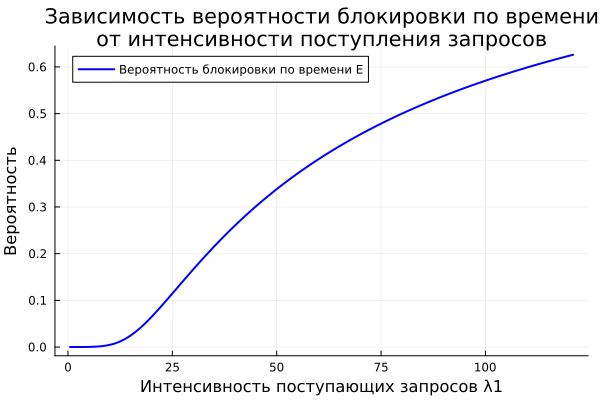

In [13]:
# 7. Построение графиков

## 7.1 График зависимости вероятности блокировки по времени E от интенсивности λ1
plot(lambda1_range, E_range,
     label = "Вероятность блокировки по времени E",
     xlabel = "Интенсивность поступающих запросов λ1",
     ylabel = "Вероятность",
     title = "Зависимость вероятности блокировки по времени\nот интенсивности поступления запросов",
     linewidth = 2,
     color = :blue,
     legend = :topleft)

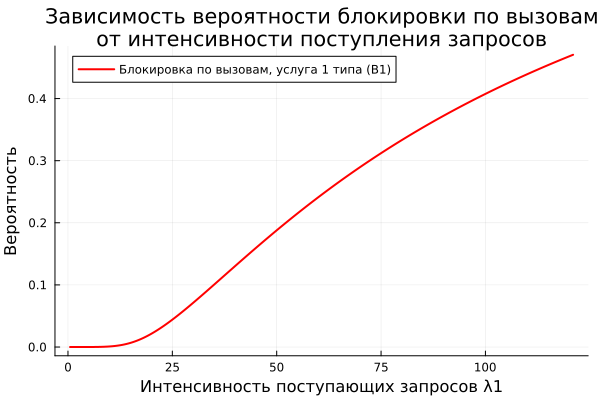

In [14]:
#№ 7.2 График зависимости вероятности блокировки по вызовам B1 (услуга 1-го типа) от интенсивности λ1
plot(lambda1_range, B1_range,
     label = "Блокировка по вызовам, услуга 1 типа (B1)",
     xlabel = "Интенсивность поступающих запросов λ1",
     ylabel = "Вероятность",
     title = "Зависимость вероятности блокировки по вызовам\nот интенсивности поступления запросов",
     linewidth = 2,
     color = :red,
     legend = :topleft)

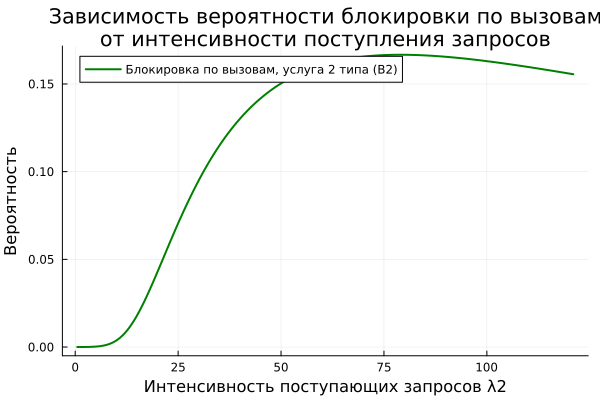

In [15]:
#№ 7.3 График зависимости вероятности блокировки по вызовам B2 (услуга 2-го типа) от интенсивности λ2
plot(lambda1_range, B2_range,
     label = "Блокировка по вызовам, услуга 2 типа (B2)",
     xlabel = "Интенсивность поступающих запросов λ2",
     ylabel = "Вероятность",
     title = "Зависимость вероятности блокировки по вызовам\nот интенсивности поступления запросов",
     linewidth = 2,
     color = :green,
     legend = :topleft)

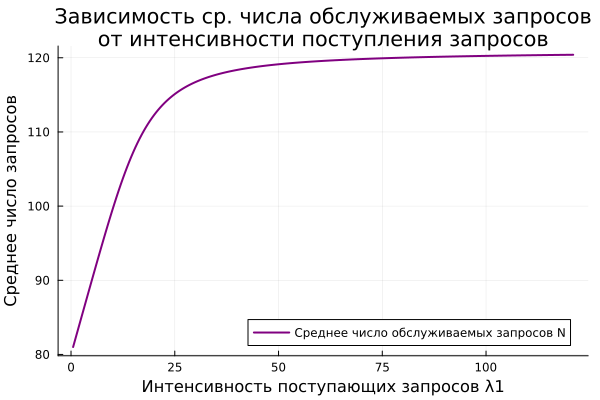

In [16]:
#№ 7.4 График зависимости среднего числа обслуживаемых запросов N от интенсивности λ1
plot(lambda1_range, N_range,
     label = "Среднее число обслуживаемых запросов N",
     xlabel = "Интенсивность поступающих запросов λ1",
     ylabel = "Среднее число запросов",
     title = "Зависимость ср. числа обслуживаемых запросов\nот интенсивности поступления запросов",
     linewidth = 2,
     color = :purple,
     legend = :bottomright)